# Combined Results – All 4 Algorithms
This notebook generates the combined results table and comparison graph for the presentation.

### 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### 2. Input All Results

In [2]:
SIZES = [10000, 20000, 40000, 60000, 80000, 100000]

# ── UBCF ──────────────────────────────────────────────────────────────────────
ubcf = pd.DataFrame({
    "Input Size":          SIZES,
    "UBCF Time (ms)":      [12776.5, 24108.5, 47897.6, 83083.5, 121596.0, 145419.3],
    "UBCF RMSE":           [1.0762,  1.0534,  1.0356,  1.0358,  1.0128,   1.0119],
    "UBCF MAE":            [0.8376,  0.8243,  0.8169,  0.8169,  0.8042,   0.8007],
})

# ── IBCF ──────────────────────────────────────────────────────────────────────
ibcf = pd.DataFrame({
    "Input Size":          SIZES,
    "IBCF Time (ms)":      [2980.5,  5347.2,  6797.5,  10124.4, 13552.6,  19691.8],
    "IBCF RMSE":           [1.0690,  1.0236,  0.9882,  0.9649,  0.9720,   0.9578],
    "IBCF MAE":            [0.8393,  0.8000,  0.7658,  0.7454,  0.7504,   0.7434],
})

# ── KNN (use K=10 as representative line for comparison) ──────────────────────
knn_k10 = pd.DataFrame({
    "Input Size":          SIZES,
    "KNN Time (ms) K=10":  [2449.20, 4488.50, 9062.57, 13597.19, 18420.99, 23471.55],
    "KNN RMSE K=10":       [1.0784,  1.0311,  1.0373,  1.0402,   1.0229,   1.0152],
    "KNN MAE K=10":        [0.8514,  0.8086,  0.8188,  0.8207,   0.8121,   0.8047],
})

# ── Matrix Factorization (SVD) ─────────────────────────────────────────────────
svd = pd.DataFrame({
    "Input Size":          SIZES,
    "SVD Time (ms)":       [4770.85, 7152.71, 13402.75, 19601.41, 25675.53, 33813.78],
    "SVD RMSE":            [1.0248,  1.0015,  0.9744,   0.9642,   0.9523,   0.9431],
    "SVD MAE":             [0.8177,  0.7896,  0.7700,   0.7556,   0.7504,   0.7426],
})

### 3. Combined Results Table

In [3]:
combined = ubcf.merge(ibcf, on="Input Size") \
               .merge(knn_k10, on="Input Size") \
               .merge(svd, on="Input Size")

combined["Input Size"] = combined["Input Size"].apply(lambda x: f"{x:,}")

print("Combined Results Table (KNN uses K=10 as representative):")
print(combined.to_string(index=False))

Combined Results Table (KNN uses K=10 as representative):
Input Size  UBCF Time (ms)  UBCF RMSE  UBCF MAE  IBCF Time (ms)  IBCF RMSE  IBCF MAE  KNN Time (ms) K=10  KNN RMSE K=10  KNN MAE K=10  SVD Time (ms)  SVD RMSE  SVD MAE
    10,000         12776.5     1.0762    0.8376          2980.5     1.0690    0.8393             2449.20         1.0784        0.8514        4770.85    1.0248   0.8177
    20,000         24108.5     1.0534    0.8243          5347.2     1.0236    0.8000             4488.50         1.0311        0.8086        7152.71    1.0015   0.7896
    40,000         47897.6     1.0356    0.8169          6797.5     0.9882    0.7658             9062.57         1.0373        0.8188       13402.75    0.9744   0.7700
    60,000         83083.5     1.0358    0.8169         10124.4     0.9649    0.7454            13597.19         1.0402        0.8207       19601.41    0.9642   0.7556
    80,000        121596.0     1.0128    0.8042         13552.6     0.9720    0.7504            18420.

### 4. Graph – Execution Time Comparison (All 4 Algorithms)

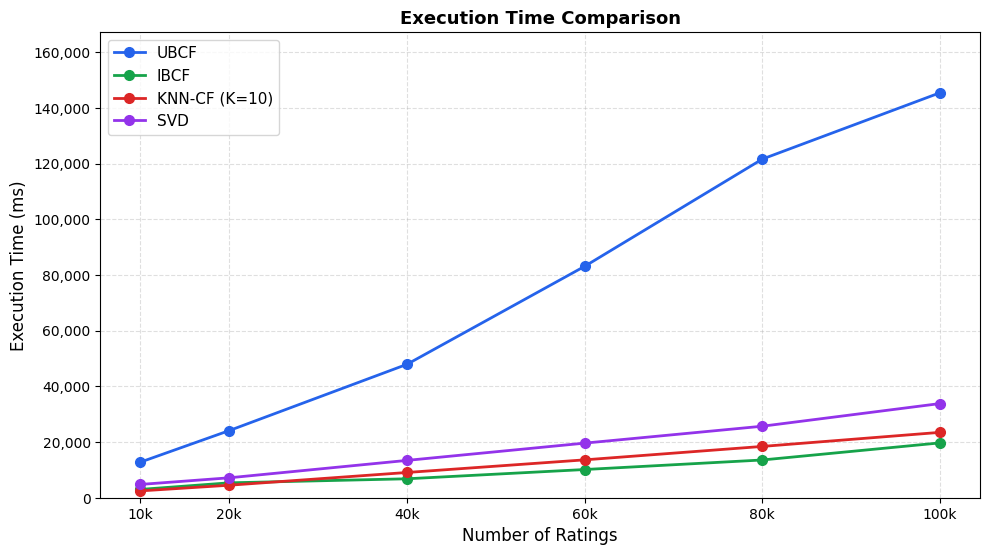

Saved: comparison_execution_time.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

lines = [
    (ubcf["UBCF Time (ms)"],         "UBCF",          "#2563EB", "o"),
    (ibcf["IBCF Time (ms)"],          "IBCF",          "#16A34A", "o"),
    (knn_k10["KNN Time (ms) K=10"],   "KNN-CF (K=10)", "#DC2626", "o"),
    (svd["SVD Time (ms)"],            "SVD",           "#9333EA", "o"),
]

for times, label, color, marker in lines:
    ax.plot(
        SIZES, times,
        label=label,
        color=color,
        marker=marker,
        linewidth=2,
        markersize=7
    )

ax.set_xlabel("Number of Ratings", fontsize=12)
ax.set_ylabel("Execution Time (ms)", fontsize=12)
ax.set_title("Execution Time Comparison",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xticks(SIZES)
ax.set_xticklabels([f"{s//1000}k" for s in SIZES])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0, max(ubcf["UBCF Time (ms)"]) * 1.15)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("comparison_execution_time.png", dpi=150)
plt.show()
print("Saved: comparison_execution_time.png")

### 5. Graph – RMSE Comparison (All 4 Algorithms)

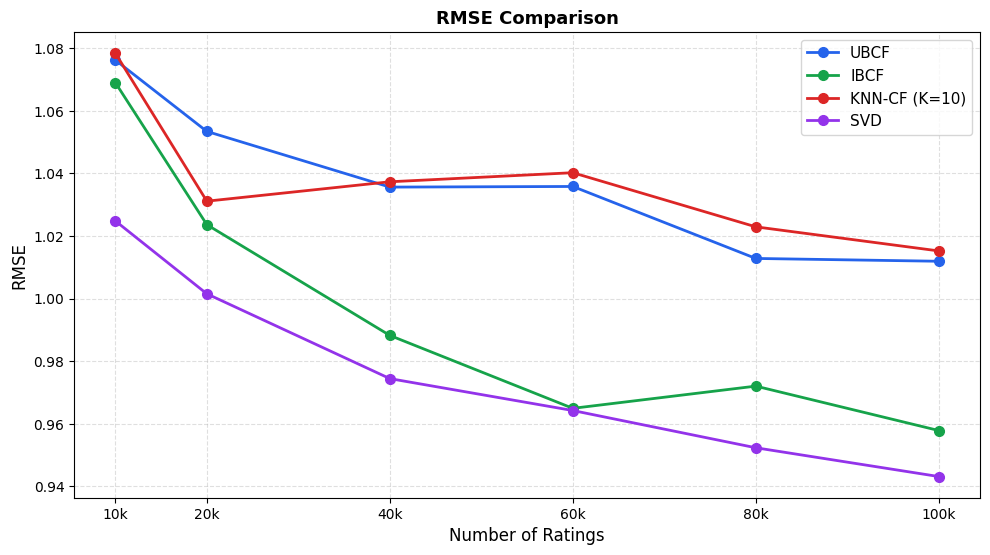

Saved: comparison_rmse.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

rmse_lines = [
    (ubcf["UBCF RMSE"],        "UBCF",          "#2563EB", "o"),
    (ibcf["IBCF RMSE"],        "IBCF",          "#16A34A", "o"),
    (knn_k10["KNN RMSE K=10"], "KNN-CF (K=10)", "#DC2626", "o"),
    (svd["SVD RMSE"],          "SVD",           "#9333EA", "o"),
]

for rmse, label, color, marker in rmse_lines:
    ax.plot(
        SIZES, rmse,
        label=label,
        color=color,
        marker=marker,
        linewidth=2,
        markersize=7
    )

ax.set_xlabel("Number of Ratings", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("RMSE Comparison",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xticks(SIZES)
ax.set_xticklabels([f"{s//1000}k" for s in SIZES])
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("comparison_rmse.png", dpi=150)
plt.show()
print("Saved: comparison_rmse.png")

### 6. KNN All K Values – Execution Time

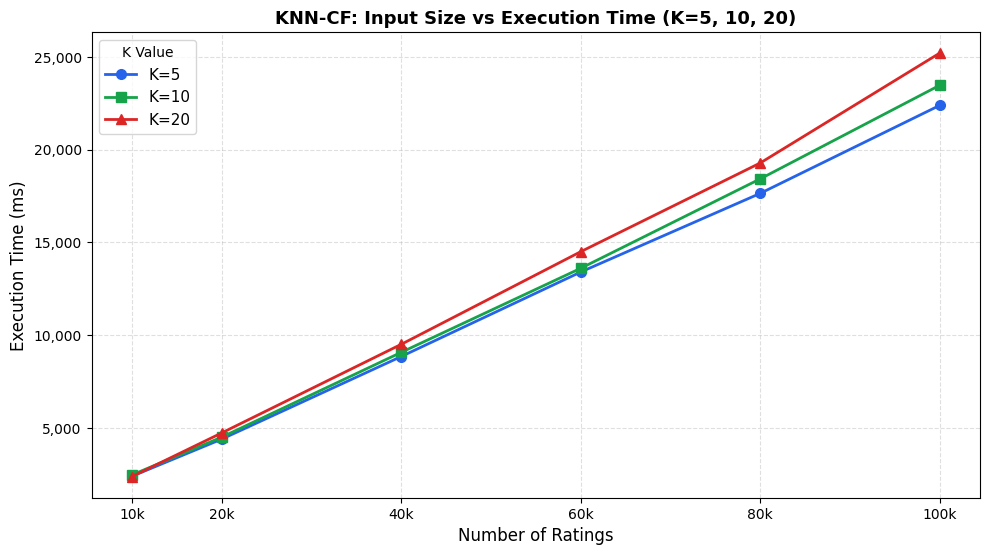

Saved: knn_all_k_execution_time.png


In [6]:
knn_all = {
    5:  [2378.26, 4381.35, 8837.39,  13395.85, 17639.38, 22386.80],
    10: [2449.20, 4488.50, 9062.57,  13597.19, 18420.99, 23471.55],
    20: [2363.00, 4715.52, 9494.63,  14492.94, 19277.70, 25205.95],
}

fig, ax = plt.subplots(figsize=(10, 6))
colors_k = {5: "#2563EB", 10: "#16A34A", 20: "#DC2626"}
markers_k = {5: "o", 10: "s", 20: "^"}

for K, times in knn_all.items():
    ax.plot(
        SIZES, times,
        label=f"K={K}",
        color=colors_k[K],
        marker=markers_k[K],
        linewidth=2,
        markersize=7
    )

ax.set_xlabel("Number of Ratings", fontsize=12)
ax.set_ylabel("Execution Time (ms)", fontsize=12)
ax.set_title("KNN-CF: Input Size vs Execution Time (K=5, 10, 20)",
             fontsize=13, fontweight="bold")
ax.legend(title="K Value", fontsize=11)
ax.set_xticks(SIZES)
ax.set_xticklabels([f"{s//1000}k" for s in SIZES])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("knn_all_k_execution_time.png", dpi=150)
plt.show()
print("Saved: knn_all_k_execution_time.png")

### 7. Summary Table – Best Result per Algorithm at 100k

In [7]:
summary = pd.DataFrame({
    "Algorithm":        ["UBCF", "IBCF", "KNN-CF (K=20)", "SVD"],
    "Exec Time (ms)":   [145419.3, 19691.8, 25205.95, 33813.78],
    "RMSE":             [1.0119, 0.9578, 1.0022, 0.9431],
    "MAE":              [0.8007, 0.7434, 0.7958, 0.7426],
    "Complexity":       ["O(U²I)", "O(I²U)", "O(U²I)", "O(E×K)"],
})

print("Summary at 100,000 ratings:")
print(summary.to_string(index=False))

Summary at 100,000 ratings:
    Algorithm  Exec Time (ms)   RMSE    MAE Complexity
         UBCF       145419.30 1.0119 0.8007     O(U²I)
         IBCF        19691.80 0.9578 0.7434     O(I²U)
KNN-CF (K=20)        25205.95 1.0022 0.7958     O(U²I)
          SVD        33813.78 0.9431 0.7426     O(E×K)
